In [1]:
from pickle import TRUE
import os
from pickletools import optimize
import splitfolders
import json
import h5py

from utils.validate import validate_images
from dataset_generator import create_dataset
from models import Autoencoder, train_network, create_data_dict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

/home/massive_rabbit/anaconda3/envs/testbench/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_to_experiments = os.path.abspath(r"../../ImageInpaintingExperiments")
if not os.path.exists(path_to_experiments):
    os.makedirs(path_to_experiments)

experiment_id = "TestBench_data"
path_to_current_experiment = os.path.join(path_to_experiments, experiment_id)
if not os.path.exists(path_to_current_experiment):
    os.makedirs(path_to_current_experiment)

config = {
    "Data": {
        "raw_img_dir": os.path.join(path_to_experiments, "training/"),
        "data_dir": os.path.join(path_to_current_experiment, "Data/"),
        "valid_img_folder": r"Valid_data",
        "log_file": "logfile.log",
        "formatter": "06d",
        "train_val_split_folder": r"Dataset",
        "seed": 1337,
        "train_val_split_ratio": (0.8, 0.2),
        "spacing_range": (2, 6),
        "offset_range": (1, 8)
    },
    "Model": {
        "lr": 5e-4,
        "path_to_model": os.path.join(path_to_current_experiment, "model.pth")
    },
    "Training": {
        "epochs": 200,
        "batch_size": 512
    }
}

FILTER_IMAGES = False
CREATE_DATASET = False
TRAIN_MODEL = False
LOG_MODEL = False
CREATE_DATA_DICTS = False

train_input_dir = os.path.join(os.path.join(config["Data"]["data_dir"], config["Data"]["train_val_split_folder"]), "train/")
val_input_dir = os.path.join(os.path.join(config["Data"]["data_dir"], config["Data"]["train_val_split_folder"]), "val/")
path_to_train_data_dict = path_to_current_experiment + "/train_data_dict.hdf5"
path_to_val_data_dict = path_to_current_experiment + "/val_data_dict.hdf5"

if CREATE_DATASET == True:
    if FILTER_IMAGES == True:
        print("Filter images:")
        print("input dir: ", config["Data"]["raw_img_dir"])

        ## Check if images are in correct format etc. ##
        valid_img_count = validate_images(
            input_dir=config["Data"]["raw_img_dir"], 
            output_dir=os.path.join(config["Data"]["data_dir"], config["Data"]["valid_img_folder"]), 
            log_file=os.path.join(config["Data"]["data_dir"], config["Data"]["log_file"]), 
            formatter=config["Data"]["formatter"]
        )
        print(f"Number of valid images: {valid_img_count}")

    print("Create dataset:")

    ## Split data into train an validation set ##
    splitfolders.ratio(
        input=config["Data"]["data_dir"], 
        output=os.path.join(config["Data"]["data_dir"], config["Data"]["train_val_split_folder"]), 
        seed=config["Data"]["seed"], 
        ratio=config["Data"]["train_val_split_ratio"]
    )
    
    print("train_input_dir: ", train_input_dir)
    print("val_input_dir: ", val_input_dir)

    ## create datasets for training and validation ##
    train_dataset, val_dataset = create_dataset(
        input_dirs=(train_input_dir, val_input_dir),
        spacing_range=config["Data"]["spacing_range"],
        offset_range=config["Data"]["offset_range"]
    )

    print(f"train_dataset length: {len(train_dataset)}")
    print(f"val_dataset length: {len(val_dataset)}")

    print("Saving datasets...")
    torch.save(train_dataset, os.path.join(path_to_current_experiment, "train_dataset.pt"))
    torch.save(val_dataset, os.path.join(path_to_current_experiment, "val_dataset.pt"))
    print("Successfully saved datasets!")
else:
    print("Loading dataset:")
    train_dataset = torch.load(os.path.join(path_to_current_experiment, "train_dataset.pt"))
    val_dataset = torch.load(os.path.join(path_to_current_experiment, "val_dataset.pt"))

    print(f"train_dataset length: {len(train_dataset)}")
    print(f"val_dataset length: {len(val_dataset)}")

train_dataloader = DataLoader(train_dataset, batch_size=config["Training"]["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
# add test dataloader

#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
print(f'Using {device} device')

Loading dataset:
train_dataset length: 23524
val_dataset length: 5882
Using cpu device


In [3]:
f, t, i, k, s, o = train_dataset[:]

In [50]:
t[0].shape

torch.Size([27450])

In [4]:
import numpy as np
idx = 1

input_image = np.moveaxis(f[idx].numpy(), 0, -1)
target_image = np.moveaxis(i[idx].numpy(), 0, -1)
spacing = s[idx]
offset = o[idx]

In [5]:
print("image shape: {target_image.shape}")
print(f"spacing: {spacing}")
print(f"offset: {offset}")

image shape: {target_image.shape}
spacing: (6, 6)
offset: (6, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


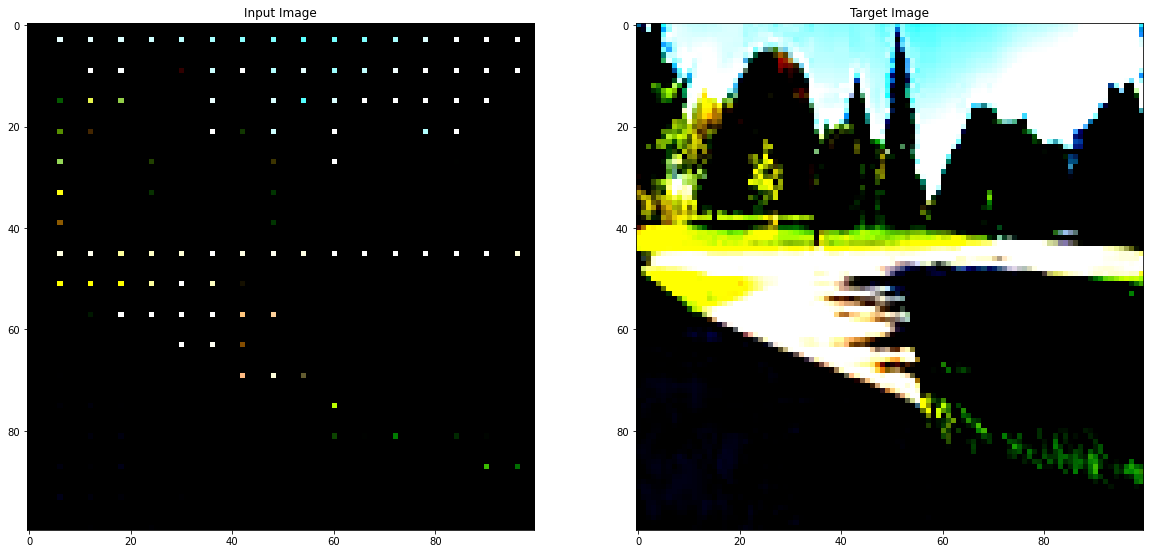

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,2, figsize=(20,20))

axs[0].imshow(input_image)
axs[0].set_title("Input Image")

axs[1].imshow(target_image)
axs[1].set_title("Target Image")

plt.show()

In [7]:
path_to_test_set = os.path.join(path_to_experiments, "supplements/example_testset.pkl")
path_to_test_submission = os.path.join(path_to_experiments, "supplements/example_submission_random.pkl")

In [8]:
path_to_experiments

'/home/massive_rabbit/Documents/ImageInpaintingExperiments'

In [9]:
print(path_to_test_set)

/home/massive_rabbit/Documents/ImageInpaintingExperiments/supplements/example_testset.pkl


In [10]:
import pickle

def open_pkl(path_to_file):
    with open(path_to_file, 'rb') as f:
        x = pickle.load(f)
        return x

In [11]:
test_set = open_pkl(path_to_test_set)
test_sub = open_pkl(path_to_test_submission)

In [41]:
print(f"Keys: {test_set.keys()}")
print(f"number of input arrays: {len(test_set['input_arrays'])}")
print(f"shape of input arrays: {test_set['input_arrays'][0].shape}")
print(f"Min val of input arrays: {test_set['input_arrays'][5].min()}")
print(f"Max val of input arrays: {test_set['input_arrays'][5].max()}")

Keys: dict_keys(['input_arrays', 'known_arrays', 'offsets', 'spacings', 'sample_ids'])
number of input arrays: 1000
shape of input arrays: (3, 100, 100)
Min val of input arrays: 0
Max val of input arrays: 255


In [48]:
(test_set["known_arrays"][0] == 0).astype(int).sum()

26619

In [43]:
test_sub[0].shape

(26619,)

In [25]:
test_sub[0].max()

255

In [51]:
target_array = test_set['input_arrays'][0][test_set["known_arrays"][0] < 1]

In [53]:
target_array.shape

(26619,)